In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
os.chdir('/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/')
from process_results import (
    get_all_runs_data,
    data_to_dataframe,
    summary_table,
    get_training_curves,
    get_available_steps,
    PASS_K_VALUES,
    DIFFICULTY_GROUPS,
    DISPLAY_NAMES,
)
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.family": "serif",
})

print("Loaded successfully")


Loaded successfully


In [2]:
# Quick summary table
summary_table()


,Run,ID (op=2-10) pass@1,ID (op=2-10) pass@128,OOD-mid (op=11-14) pass@1,OOD-mid (op=11-14) pass@128,OOD-hard (op=17-20) pass@1,OOD-hard (op=17-20) pass@128
0,Base,87.8,99.2,36.0,77.0,14.3,45.4
1,DR-GSPO (ID),90.4,97.7,36.0,67.6,14.6,38.4
2,DR-GSPO (Edge),62.1,92.9,64.6,91.3,18.7,54.5
3,DR-GSPO (Mixed),89.1,97.3,59.8,89.6,20.6,62.9
4,DR-GSPO (Hard),51.5,82.7,29.1,85.8,19.8,59.7
5,DR-GSPO-ClipCov (ID),90.3,97.6,36.7,66.0,14.4,38.7
6,DR-GSPO-ClipCov (Edge),75.2,95.9,65.1,92.3,18.7,54.8
7,DR-GSPO-ClipCov (Mixed),88.3,97.6,59.4,89.6,20.5,63.2
8,DR-GSPO-ClipCov (Hard),54.6,88.2,26.4,84.4,20.3,63.3
9,DR-GSPO-MGPO (ID),89.9,97.5,35.1,66.1,14.5,38.0


In [3]:
# ── Main Plot: DR-GSPO ClipCov vs Standard DR-GSPO (+ Base) ────────────────────
# Mirrors the style from the reference image: 3 subplots (ID, OOD-mid, OOD-hard)
# Each line = one RL run, x-axis = pass@k, y-axis = performance (%)

def plot_pass_at_k(
    run_groups: dict[str, list[str]],
    title: str = "",
    colors: dict[str, str] | None = None,
    markers: dict[str, str] | None = None,
    linestyles: dict[str, str] | None = None,
    figsize: tuple = (16, 4.5),
    ylim_per_group: dict[str, tuple] | None = None,
    save_path: str | None = None,
):
    """
    Plot pass@k curves for multiple runs across the three difficulty groups.

    Args:
        run_groups: dict mapping display_label -> list of run_names
                    (if list has 1 entry, just that run; multiple = shouldn't happen normally)
        title: super title
        colors: mapping display_label -> color
        markers: mapping display_label -> marker style
        linestyles: mapping display_label -> linestyle
        figsize: figure size
        ylim_per_group: optional per-subplot y limits
        save_path: if given, save figure to this path
    """
    group_names = list(DIFFICULTY_GROUPS.keys())
    k_values = PASS_K_VALUES

    # Load data for all runs
    all_run_names = []
    for runs in run_groups.values():
        all_run_names.extend(runs)
    all_run_names = list(set(all_run_names))
    all_data = get_all_runs_data(all_run_names)

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=False)

    for ax_idx, group_name in enumerate(group_names):
        ax = axes[ax_idx]

        for label, run_names in run_groups.items():
            run_name = run_names[0]  # use first run
            if run_name not in all_data:
                continue
            pass_k_dict = all_data[run_name][group_name]
            y_vals = [pass_k_dict[k] * 100 for k in k_values]

            color = colors.get(label) if colors else None
            marker = (markers.get(label) if markers else None) or "o"
            ls = (linestyles.get(label) if linestyles else None) or "-"

            ax.plot(
                range(len(k_values)), y_vals,
                marker=marker, markersize=5, linewidth=1.8,
                color=color, linestyle=ls,
                label=label if ax_idx == 0 else None,
            )

        ax.set_title(group_name, fontweight="bold")
        ax.set_xticks(range(len(k_values)))
        ax.set_xticklabels([str(k) for k in k_values])
        ax.set_xlabel("pass@k")
        ax.grid(True, alpha=0.3, linestyle="--")

        if ylim_per_group and group_name in ylim_per_group:
            ax.set_ylim(ylim_per_group[group_name])

    axes[0].set_ylabel("performance (%)")
    axes[0].legend(loc="lower right", framealpha=0.9, handlelength=3.0)

    if title:
        fig.suptitle(title, fontweight="bold", fontsize=15, y=1.02)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig


Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_clipcov_vs_standard.png


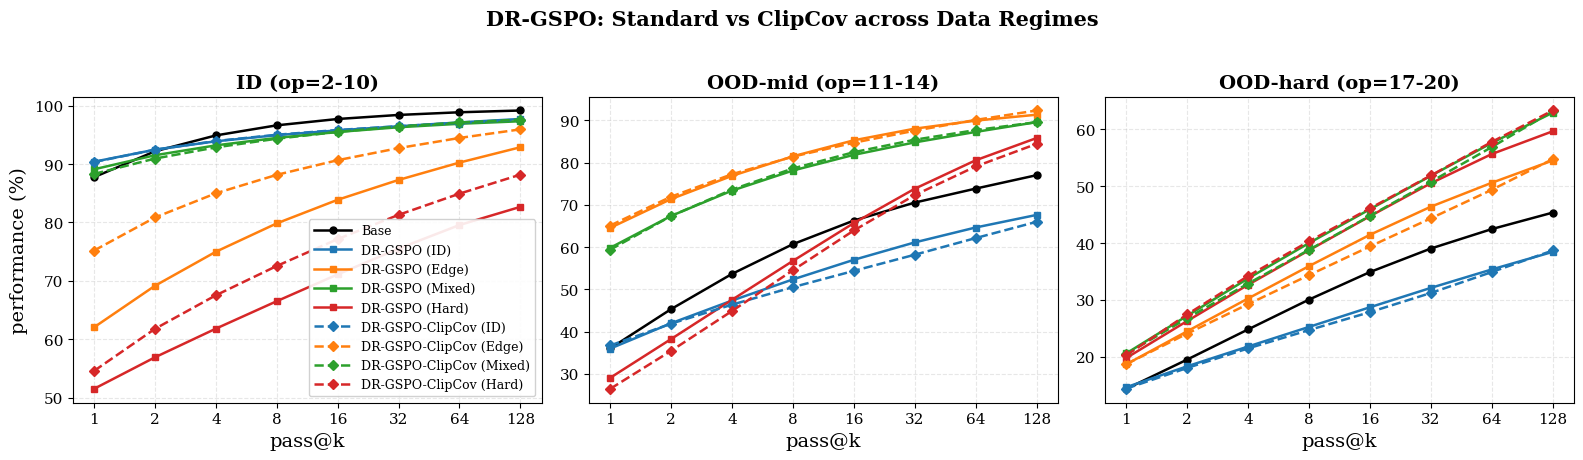

In [4]:
# ── Plot 1: DR-GSPO ClipCov vs Standard DR-GSPO across data regimes ───────────
# This is the main comparison: clip_cov vs standard, across id/edge/mixed/hard

run_groups_clipcov_vs_standard = {
    "Base":                     ["base_model_eval_pass128"],
    "DR-GSPO (ID)":             ["dr_gspo_id"],
    "DR-GSPO (Edge)":           ["dr_gspo_edge"],
    "DR-GSPO (Mixed)":          ["dr_gspo_mixed"],
    "DR-GSPO (Hard)":           ["dr_gspo_hard"],
    "DR-GSPO-ClipCov (ID)":     ["dr_gspo_clip_cov_id"],
    "DR-GSPO-ClipCov (Edge)":   ["dr_gspo_clip_cov_edge"],
    "DR-GSPO-ClipCov (Mixed)":  ["dr_gspo_clip_cov_mixed"],
    "DR-GSPO-ClipCov (Hard)":   ["dr_gspo_clip_cov_hard"],
}

colors_clipcov = {
    "Base":                     "black",
    "DR-GSPO (ID)":             "#1f77b4",   # blue
    "DR-GSPO (Edge)":           "#ff7f0e",   # orange
    "DR-GSPO (Mixed)":          "#2ca02c",   # green
    "DR-GSPO (Hard)":           "#d62728",   # red
    "DR-GSPO-ClipCov (ID)":     "#1f77b4",   # blue (dashed)
    "DR-GSPO-ClipCov (Edge)":   "#ff7f0e",   # orange (dashed)
    "DR-GSPO-ClipCov (Mixed)":  "#2ca02c",   # green (dashed)
    "DR-GSPO-ClipCov (Hard)":   "#d62728",   # red (dashed)
}

markers_clipcov = {
    "Base":                     "o",
    "DR-GSPO (ID)":             "s",
    "DR-GSPO (Edge)":           "s",
    "DR-GSPO (Mixed)":          "s",
    "DR-GSPO (Hard)":           "s",
    "DR-GSPO-ClipCov (ID)":     "D",
    "DR-GSPO-ClipCov (Edge)":   "D",
    "DR-GSPO-ClipCov (Mixed)":  "D",
    "DR-GSPO-ClipCov (Hard)":   "D",
}

linestyles_clipcov = {
    "Base":                     "-",
    "DR-GSPO (ID)":             "-",
    "DR-GSPO (Edge)":           "-",
    "DR-GSPO (Mixed)":          "-",
    "DR-GSPO (Hard)":           "-",
    "DR-GSPO-ClipCov (ID)":     "--",
    "DR-GSPO-ClipCov (Edge)":   "--",
    "DR-GSPO-ClipCov (Mixed)":  "--",
    "DR-GSPO-ClipCov (Hard)":   "--",
}

fig1 = plot_pass_at_k(
    run_groups_clipcov_vs_standard,
    title="DR-GSPO: Standard vs ClipCov across Data Regimes",
    colors=colors_clipcov,
    markers=markers_clipcov,
    linestyles=linestyles_clipcov,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_clipcov_vs_standard.png",
)


Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_vs_grpo.png


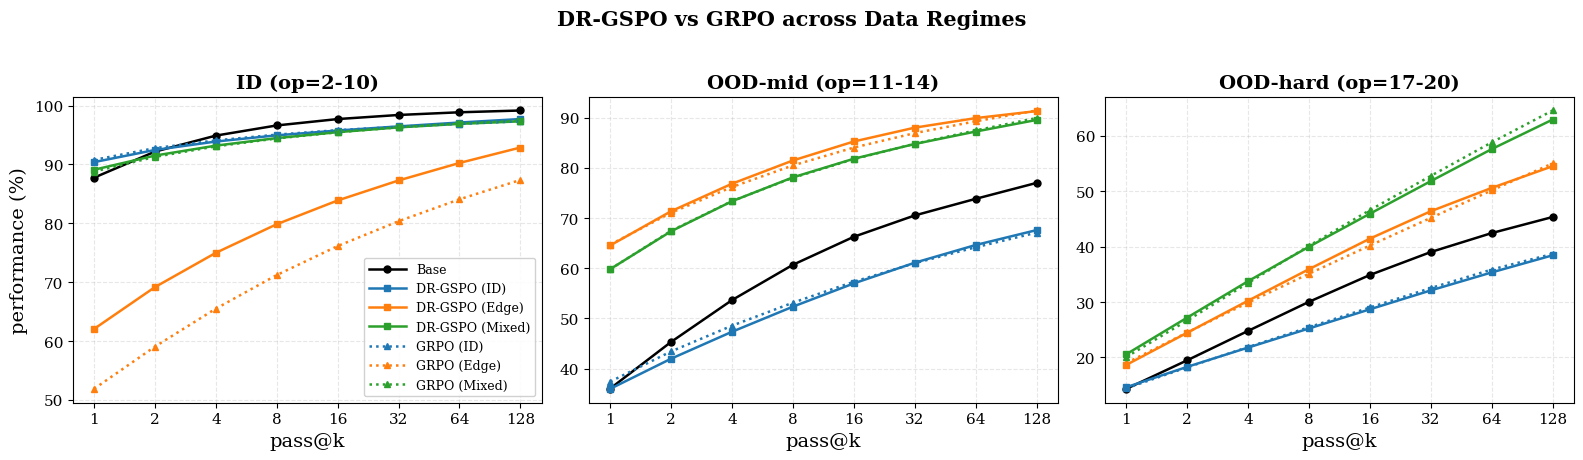

In [5]:
# ── Plot 2: DR-GSPO vs GRPO (secondary comparison) ───────────────────────────
# Show that DR-GSPO is better than GRPO across data regimes

run_groups_drgspo_vs_grpo = {
    "Base":              ["base_model_eval_pass128"],
    "DR-GSPO (ID)":      ["dr_gspo_id"],
    "DR-GSPO (Edge)":    ["dr_gspo_edge"],
    "DR-GSPO (Mixed)":   ["dr_gspo_mixed"],
    "GRPO (ID)":         ["grpo_id"],
    "GRPO (Edge)":       ["grpo_edge"],
    "GRPO (Mixed)":      ["grpo_mixed"],
}

colors_drgspo_grpo = {
    "Base":              "black",
    "DR-GSPO (ID)":      "#1f77b4",   # blue
    "DR-GSPO (Edge)":    "#ff7f0e",   # orange
    "DR-GSPO (Mixed)":   "#2ca02c",   # green
    "GRPO (ID)":         "#1f77b4",
    "GRPO (Edge)":       "#ff7f0e",
    "GRPO (Mixed)":      "#2ca02c",
}

markers_drgspo_grpo = {
    "Base":              "o",
    "DR-GSPO (ID)":      "s",
    "DR-GSPO (Edge)":    "s",
    "DR-GSPO (Mixed)":   "s",
    "GRPO (ID)":         "^",
    "GRPO (Edge)":       "^",
    "GRPO (Mixed)":      "^",
}

linestyles_drgspo_grpo = {
    "Base":              "-",
    "DR-GSPO (ID)":      "-",
    "DR-GSPO (Edge)":    "-",
    "DR-GSPO (Mixed)":   "-",
    "GRPO (ID)":         ":",
    "GRPO (Edge)":       ":",
    "GRPO (Mixed)":      ":",
}

fig2 = plot_pass_at_k(
    run_groups_drgspo_vs_grpo,
    title="DR-GSPO vs GRPO across Data Regimes",
    colors=colors_drgspo_grpo,
    markers=markers_drgspo_grpo,
    linestyles=linestyles_drgspo_grpo,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_vs_grpo.png",
)


Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_all_models.png


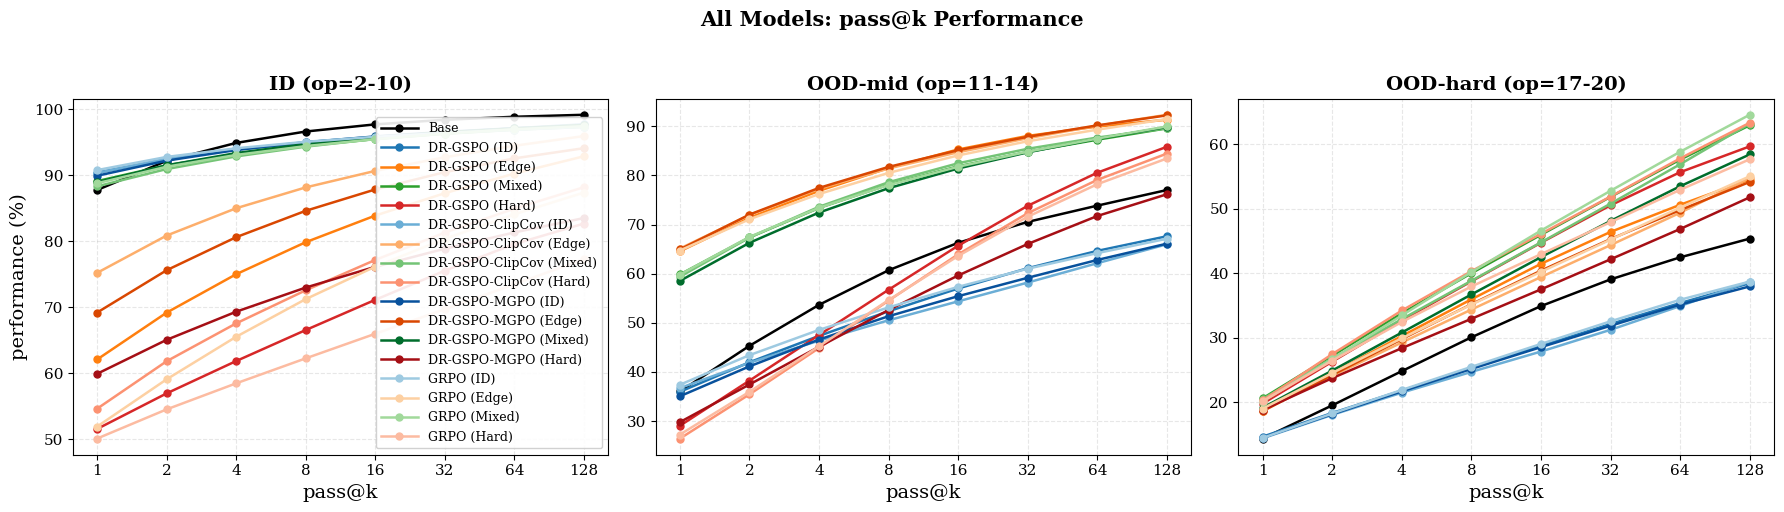

In [6]:
# ── Plot 3: All models (comprehensive) ────────────────────────────────────────
# Reference-image style: one line per RL run, Base as anchor
# Now includes Hard and MGPO variants

run_groups_all = {
    "Base":                     ["base_model_eval_pass128"],
    # DR-GSPO standard
    "DR-GSPO (ID)":             ["dr_gspo_id"],
    "DR-GSPO (Edge)":           ["dr_gspo_edge"],
    "DR-GSPO (Mixed)":          ["dr_gspo_mixed"],
    "DR-GSPO (Hard)":           ["dr_gspo_hard"],
    # DR-GSPO ClipCov
    "DR-GSPO-ClipCov (ID)":     ["dr_gspo_clip_cov_id"],
    "DR-GSPO-ClipCov (Edge)":   ["dr_gspo_clip_cov_edge"],
    "DR-GSPO-ClipCov (Mixed)":  ["dr_gspo_clip_cov_mixed"],
    "DR-GSPO-ClipCov (Hard)":   ["dr_gspo_clip_cov_hard"],
    # DR-GSPO MGPO
    "DR-GSPO-MGPO (ID)":        ["dr_gspo_mgpo_id"],
    "DR-GSPO-MGPO (Edge)":      ["dr_gspo_mgpo_edge"],
    "DR-GSPO-MGPO (Mixed)":     ["dr_gspo_mgpo_mixed"],
    "DR-GSPO-MGPO (Hard)":      ["dr_gspo_mgpo_hard"],
    # GRPO
    "GRPO (ID)":                ["grpo_id"],
    "GRPO (Edge)":              ["grpo_edge"],
    "GRPO (Mixed)":             ["grpo_mixed"],
    "GRPO (Hard)":              ["grpo_hard"],
}

# Use a rich colormap - group by data regime
colors_all = {
    "Base":                     "black",
    # ID runs - shades of blue
    "DR-GSPO (ID)":             "#1f77b4",
    "DR-GSPO-ClipCov (ID)":     "#6baed6",
    "DR-GSPO-MGPO (ID)":        "#08519c",
    "GRPO (ID)":                "#9ecae1",
    # Edge runs - shades of orange
    "DR-GSPO (Edge)":           "#ff7f0e",
    "DR-GSPO-ClipCov (Edge)":   "#fdae6b",
    "DR-GSPO-MGPO (Edge)":      "#d94701",
    "GRPO (Edge)":              "#fdd0a2",
    # Mixed runs - shades of green
    "DR-GSPO (Mixed)":          "#2ca02c",
    "DR-GSPO-ClipCov (Mixed)":  "#74c476",
    "DR-GSPO-MGPO (Mixed)":     "#006d2c",
    "GRPO (Mixed)":             "#a1d99b",
    # Hard runs - shades of red
    "DR-GSPO (Hard)":           "#d62728",
    "DR-GSPO-ClipCov (Hard)":   "#fc9272",
    "DR-GSPO-MGPO (Hard)":      "#a50f15",
    "GRPO (Hard)":              "#fcbba1",
}

fig3 = plot_pass_at_k(
    run_groups_all,
    title="All Models: pass@k Performance",
    colors=colors_all,
    figsize=(18, 5),
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_all_models.png",
)


Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_vs_mgpo.png


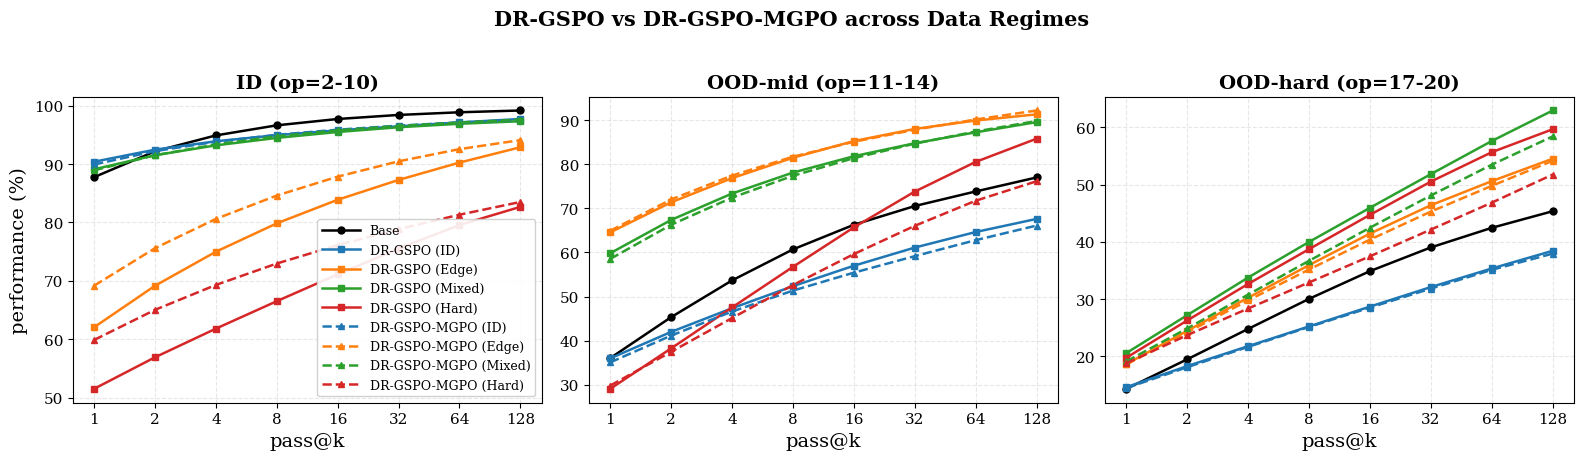

In [7]:
# ── Plot 4: DR-GSPO vs DR-GSPO-MGPO ───────────────────────────────────────────
# Compare standard DR-GSPO with MGPO variant across all data regimes

run_groups_drgspo_vs_mgpo = {
    "Base":                  ["base_model_eval_pass128"],
    "DR-GSPO (ID)":          ["dr_gspo_id"],
    "DR-GSPO (Edge)":        ["dr_gspo_edge"],
    "DR-GSPO (Mixed)":       ["dr_gspo_mixed"],
    "DR-GSPO (Hard)":        ["dr_gspo_hard"],
    "DR-GSPO-MGPO (ID)":     ["dr_gspo_mgpo_id"],
    "DR-GSPO-MGPO (Edge)":   ["dr_gspo_mgpo_edge"],
    "DR-GSPO-MGPO (Mixed)":  ["dr_gspo_mgpo_mixed"],
    "DR-GSPO-MGPO (Hard)":   ["dr_gspo_mgpo_hard"],
}

colors_drgspo_mgpo = {
    "Base":                  "black",
    "DR-GSPO (ID)":          "#1f77b4",   # blue
    "DR-GSPO (Edge)":        "#ff7f0e",   # orange
    "DR-GSPO (Mixed)":       "#2ca02c",   # green
    "DR-GSPO (Hard)":        "#d62728",   # red
    "DR-GSPO-MGPO (ID)":     "#1f77b4",   # blue (dashed)
    "DR-GSPO-MGPO (Edge)":   "#ff7f0e",   # orange (dashed)
    "DR-GSPO-MGPO (Mixed)":  "#2ca02c",   # green (dashed)
    "DR-GSPO-MGPO (Hard)":   "#d62728",   # red (dashed)
}

markers_drgspo_mgpo = {
    "Base":                  "o",
    "DR-GSPO (ID)":          "s",
    "DR-GSPO (Edge)":        "s",
    "DR-GSPO (Mixed)":       "s",
    "DR-GSPO (Hard)":        "s",
    "DR-GSPO-MGPO (ID)":     "^",
    "DR-GSPO-MGPO (Edge)":   "^",
    "DR-GSPO-MGPO (Mixed)":  "^",
    "DR-GSPO-MGPO (Hard)":   "^",
}

linestyles_drgspo_mgpo = {
    "Base":                  "-",
    "DR-GSPO (ID)":          "-",
    "DR-GSPO (Edge)":        "-",
    "DR-GSPO (Mixed)":       "-",
    "DR-GSPO (Hard)":        "-",
    "DR-GSPO-MGPO (ID)":     "--",
    "DR-GSPO-MGPO (Edge)":   "--",
    "DR-GSPO-MGPO (Mixed)":  "--",
    "DR-GSPO-MGPO (Hard)":   "--",
}

fig4 = plot_pass_at_k(
    run_groups_drgspo_vs_mgpo,
    title="DR-GSPO vs DR-GSPO-MGPO across Data Regimes",
    colors=colors_drgspo_mgpo,
    markers=markers_drgspo_mgpo,
    linestyles=linestyles_drgspo_mgpo,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_vs_mgpo.png",
)


Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_grpo_vs_mgpo.png


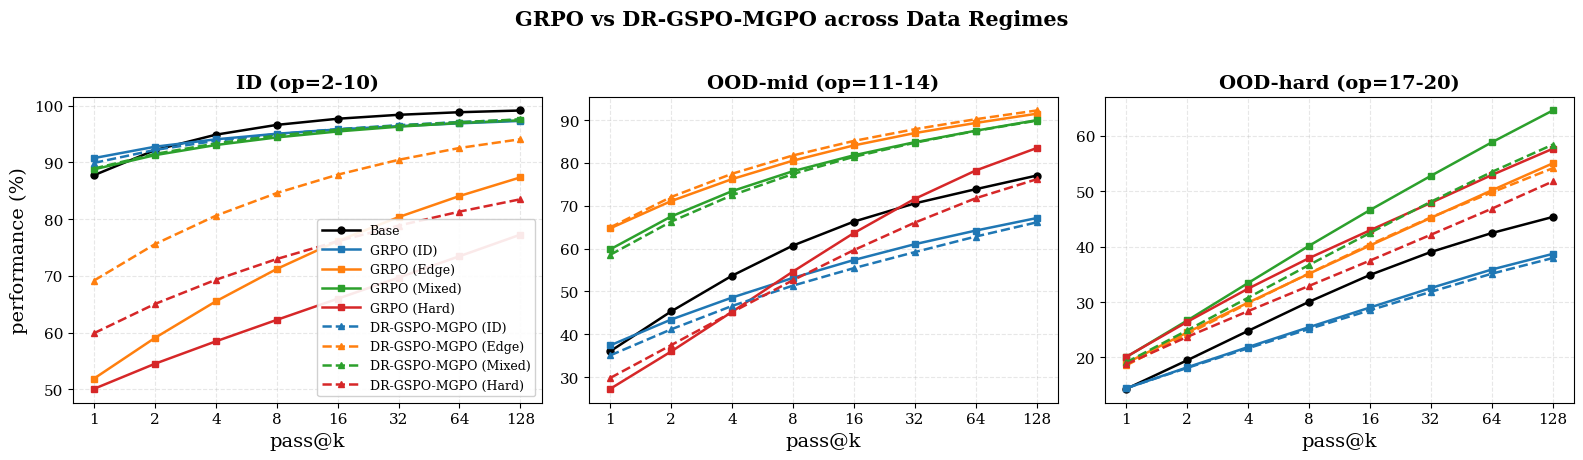

In [8]:
# ── Plot 5: GRPO vs DR-GSPO-MGPO ──────────────────────────────────────────────
# Compare standard GRPO with DR-GSPO-MGPO across all data regimes

run_groups_grpo_vs_mgpo = {
    "Base":                  ["base_model_eval_pass128"],
    "GRPO (ID)":             ["grpo_id"],
    "GRPO (Edge)":           ["grpo_edge"],
    "GRPO (Mixed)":          ["grpo_mixed"],
    "GRPO (Hard)":           ["grpo_hard"],
    "DR-GSPO-MGPO (ID)":     ["dr_gspo_mgpo_id"],
    "DR-GSPO-MGPO (Edge)":   ["dr_gspo_mgpo_edge"],
    "DR-GSPO-MGPO (Mixed)":  ["dr_gspo_mgpo_mixed"],
    "DR-GSPO-MGPO (Hard)":   ["dr_gspo_mgpo_hard"],
}

colors_grpo_mgpo = {
    "Base":                  "black",
    "GRPO (ID)":             "#1f77b4",   # blue
    "GRPO (Edge)":           "#ff7f0e",   # orange
    "GRPO (Mixed)":          "#2ca02c",   # green
    "GRPO (Hard)":           "#d62728",   # red
    "DR-GSPO-MGPO (ID)":     "#1f77b4",   # blue (dashed)
    "DR-GSPO-MGPO (Edge)":   "#ff7f0e",   # orange (dashed)
    "DR-GSPO-MGPO (Mixed)":  "#2ca02c",   # green (dashed)
    "DR-GSPO-MGPO (Hard)":   "#d62728",   # red (dashed)
}

markers_grpo_mgpo = {
    "Base":                  "o",
    "GRPO (ID)":             "s",
    "GRPO (Edge)":           "s",
    "GRPO (Mixed)":          "s",
    "GRPO (Hard)":           "s",
    "DR-GSPO-MGPO (ID)":     "^",
    "DR-GSPO-MGPO (Edge)":   "^",
    "DR-GSPO-MGPO (Mixed)":  "^",
    "DR-GSPO-MGPO (Hard)":   "^",
}

linestyles_grpo_mgpo = {
    "Base":                  "-",
    "GRPO (ID)":             "-",
    "GRPO (Edge)":           "-",
    "GRPO (Mixed)":          "-",
    "GRPO (Hard)":           "-",
    "DR-GSPO-MGPO (ID)":     "--",
    "DR-GSPO-MGPO (Edge)":   "--",
    "DR-GSPO-MGPO (Mixed)":  "--",
    "DR-GSPO-MGPO (Hard)":   "--",
}

fig5 = plot_pass_at_k(
    run_groups_grpo_vs_mgpo,
    title="GRPO vs DR-GSPO-MGPO across Data Regimes",
    colors=colors_grpo_mgpo,
    markers=markers_grpo_mgpo,
    linestyles=linestyles_grpo_mgpo,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_grpo_vs_mgpo.png",
)


Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_vs_rup.png


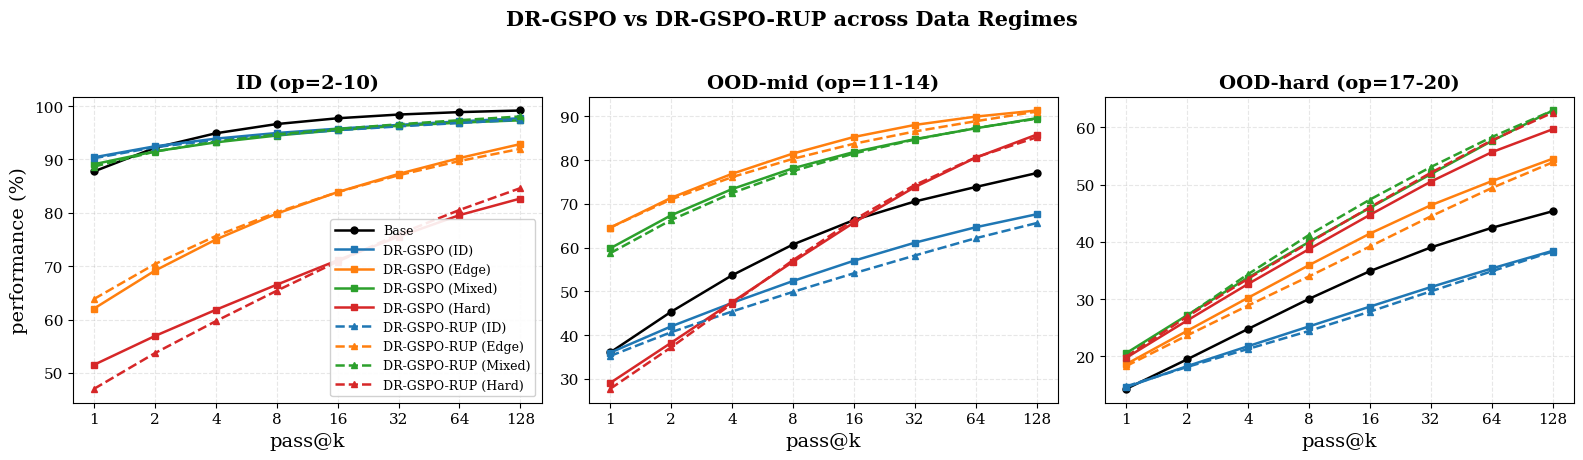

In [9]:
# ── Plot 6: DR-GSPO vs DR-GSPO-RUP ────────────────────────────────────────────
# Compare standard DR-GSPO with RUP variant across all data regimes

run_groups_drgspo_vs_rup = {
    "Base":                 ["base_model_eval_pass128"],
    "DR-GSPO (ID)":         ["dr_gspo_id"],
    "DR-GSPO (Edge)":       ["dr_gspo_edge"],
    "DR-GSPO (Mixed)":      ["dr_gspo_mixed"],
    "DR-GSPO (Hard)":       ["dr_gspo_hard"],
    "DR-GSPO-RUP (ID)":     ["dr_gspo_rup_id"],
    "DR-GSPO-RUP (Edge)":   ["dr_gspo_rup_edge"],
    "DR-GSPO-RUP (Mixed)":  ["dr_gspo_rup_mixed"],
    "DR-GSPO-RUP (Hard)":   ["dr_gspo_rup_hard"],
}

colors_drgspo_rup = {
    "Base":                 "black",
    "DR-GSPO (ID)":         "#1f77b4",   # blue
    "DR-GSPO (Edge)":       "#ff7f0e",   # orange
    "DR-GSPO (Mixed)":      "#2ca02c",   # green
    "DR-GSPO (Hard)":       "#d62728",   # red
    "DR-GSPO-RUP (ID)":     "#1f77b4",   # blue (dashed)
    "DR-GSPO-RUP (Edge)":   "#ff7f0e",   # orange (dashed)
    "DR-GSPO-RUP (Mixed)":  "#2ca02c",   # green (dashed)
    "DR-GSPO-RUP (Hard)":   "#d62728",   # red (dashed)
}

markers_drgspo_rup = {
    "Base":                 "o",
    "DR-GSPO (ID)":         "s",
    "DR-GSPO (Edge)":       "s",
    "DR-GSPO (Mixed)":      "s",
    "DR-GSPO (Hard)":       "s",
    "DR-GSPO-RUP (ID)":     "^",
    "DR-GSPO-RUP (Edge)":   "^",
    "DR-GSPO-RUP (Mixed)":  "^",
    "DR-GSPO-RUP (Hard)":   "^",
}

linestyles_drgspo_rup = {
    "Base":                 "-",
    "DR-GSPO (ID)":         "-",
    "DR-GSPO (Edge)":       "-",
    "DR-GSPO (Mixed)":      "-",
    "DR-GSPO (Hard)":       "-",
    "DR-GSPO-RUP (ID)":     "--",
    "DR-GSPO-RUP (Edge)":   "--",
    "DR-GSPO-RUP (Mixed)":  "--",
    "DR-GSPO-RUP (Hard)":   "--",
}

fig6 = plot_pass_at_k(
    run_groups_drgspo_vs_rup,
    title="DR-GSPO vs DR-GSPO-RUP across Data Regimes",
    colors=colors_drgspo_rup,
    markers=markers_drgspo_rup,
    linestyles=linestyles_drgspo_rup,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_vs_rup.png",
)

Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_variants_mixed.png


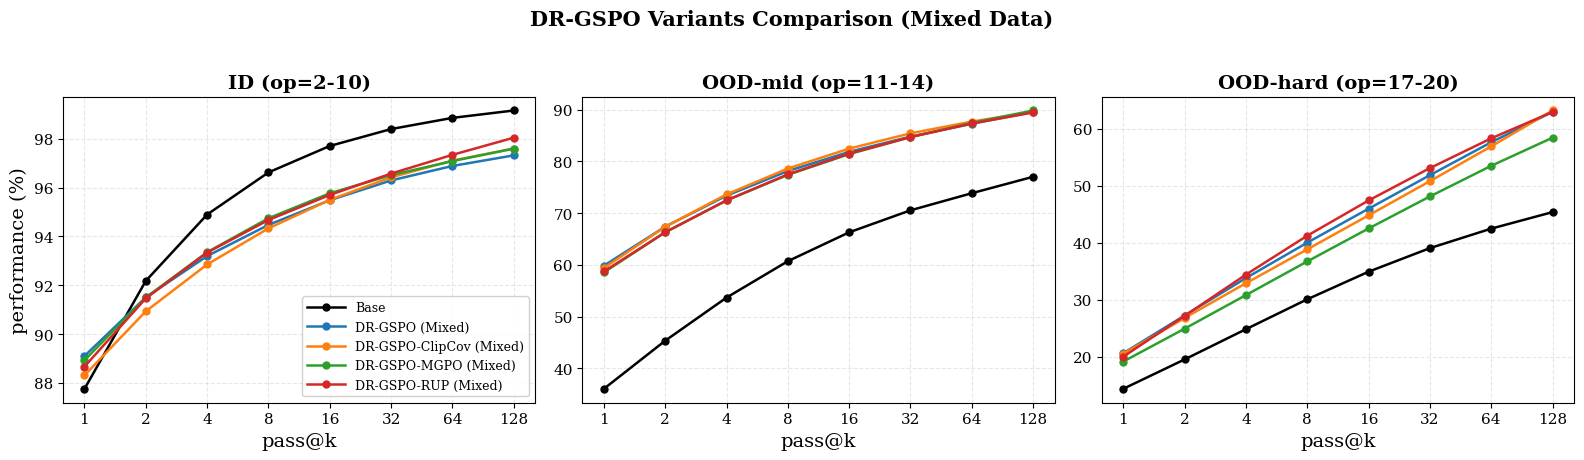

In [10]:
# ── Plot 7: All DR-GSPO variants comparison ──────────────────────────────────
# Compare all DR-GSPO variants: standard, ClipCov, MGPO, RUP on a single data regime (Mixed)

run_groups_drgspo_variants_mixed = {
    "Base":                     ["base_model_eval_pass128"],
    "DR-GSPO (Mixed)":          ["dr_gspo_mixed"],
    "DR-GSPO-ClipCov (Mixed)":  ["dr_gspo_clip_cov_mixed"],
    "DR-GSPO-MGPO (Mixed)":     ["dr_gspo_mgpo_mixed"],
    "DR-GSPO-RUP (Mixed)":      ["dr_gspo_rup_mixed"],
}

colors_variants = {
    "Base":                     "black",
    "DR-GSPO (Mixed)":          "#1f77b4",   # blue
    "DR-GSPO-ClipCov (Mixed)":  "#ff7f0e",   # orange
    "DR-GSPO-MGPO (Mixed)":     "#2ca02c",   # green
    "DR-GSPO-RUP (Mixed)":      "#d62728",   # red
}

fig7 = plot_pass_at_k(
    run_groups_drgspo_variants_mixed,
    title="DR-GSPO Variants Comparison (Mixed Data)",
    colors=colors_variants,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_drgspo_variants_mixed.png",
)

Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_training_curves_mixed.png


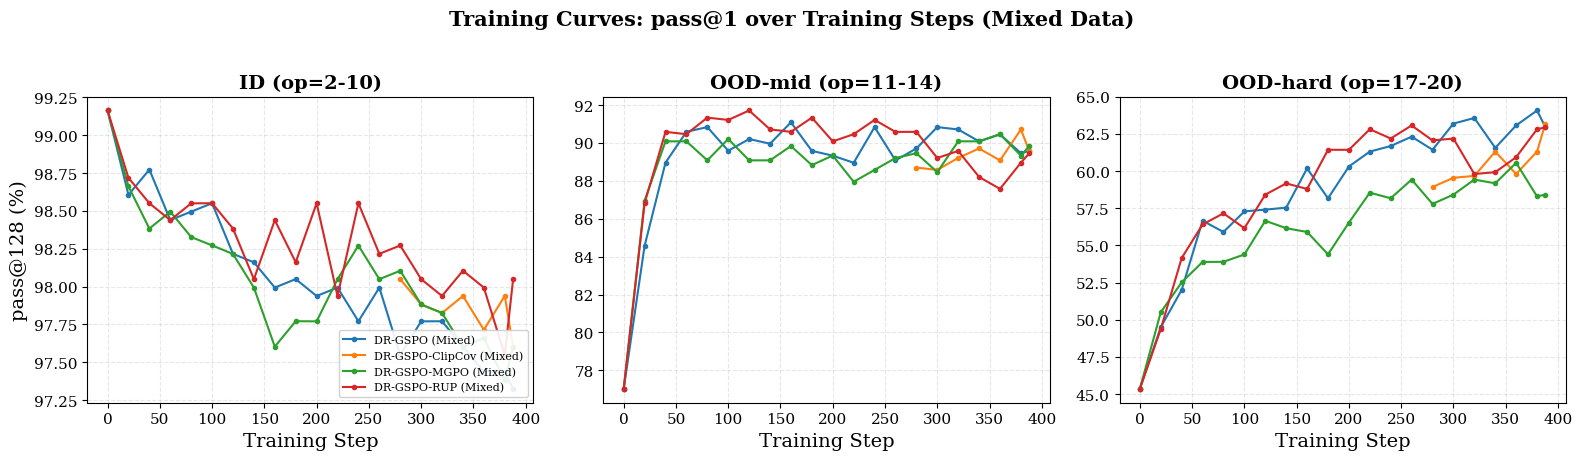

In [18]:
# ── Plot 8: Training curves (pass@1 over training steps) ─────────────────────
# Show how pass@1 evolves during training for different runs

def plot_training_curves(
    run_names: list[str],
    k: int = 1,
    title: str = "",
    colors: dict[str, str] | None = None,
    linestyles: dict[str, str] | None = None,
    figsize: tuple = (16, 4.5),
    save_path: str | None = None,
    steps: list[int] | None = None,
):
    """Plot pass@k training curves across the three difficulty groups."""
    group_names = list(DIFFICULTY_GROUPS.keys())
    
    # Load training curves
    df = get_training_curves(run_names, k=k, steps=steps)
    
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=False)
    
    for ax_idx, group_name in enumerate(group_names):
        ax = axes[ax_idx]
        group_df = df[df["group"] == group_name]
        
        for run_name in run_names:
            run_df = group_df[group_df["run"] == run_name]
            if run_df.empty:
                continue
            
            display_name = DISPLAY_NAMES.get(run_name, run_name)
            color = colors.get(display_name) if colors else None
            ls = (linestyles.get(display_name) if linestyles else None) or "-"
            
            ax.plot(
                run_df["step"], run_df["pass_at_k"],
                marker="o", markersize=3, linewidth=1.5,
                color=color, linestyle=ls,
                label=display_name if ax_idx == 0 else None,
            )
        
        ax.set_title(group_name, fontweight="bold")
        ax.set_xlabel("Training Step")
        ax.grid(True, alpha=0.3, linestyle="--")
    
    axes[0].set_ylabel(f"pass@{k} (%)")
    axes[0].legend(loc="lower right", framealpha=0.9, fontsize=8)
    
    if title:
        fig.suptitle(title, fontweight="bold", fontsize=15, y=1.02)
    fig.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to {save_path}")
    
    plt.show()
    return fig

# Training curves for DR-GSPO variants on Mixed data
training_runs_mixed = [
    "dr_gspo_mixed",
    "dr_gspo_clip_cov_mixed",
    "dr_gspo_mgpo_mixed",
    "dr_gspo_rup_mixed",
]

training_colors = {
    "DR-GSPO (Mixed)":          "#1f77b4",
    "DR-GSPO-ClipCov (Mixed)":  "#ff7f0e",
    "DR-GSPO-MGPO (Mixed)":     "#2ca02c",
    "DR-GSPO-RUP (Mixed)":      "#d62728",
}

fig8 = plot_training_curves(
    training_runs_mixed,
    k=128,
    title="Training Curves: pass@1 over Training Steps (Mixed Data)",
    colors=training_colors,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_training_curves_mixed.png",
)

Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_training_curves_edge.png


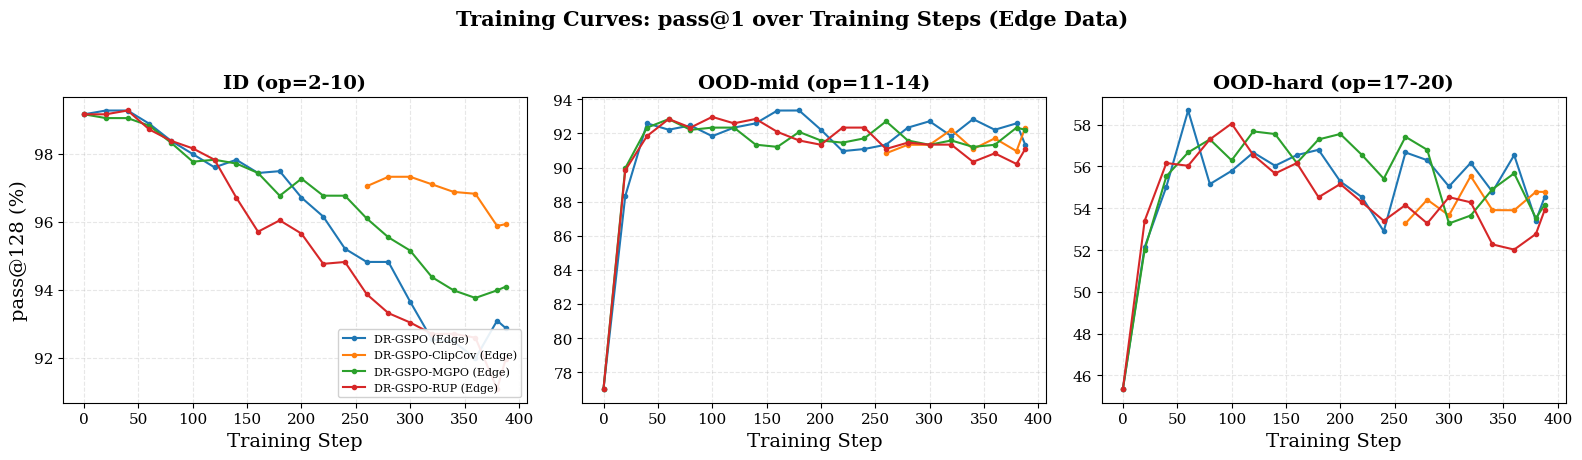

In [17]:
# ── Plot 9: Training curves for Edge data regime ─────────────────────────────

training_runs_edge = [
    "dr_gspo_edge",
    "dr_gspo_clip_cov_edge",
    "dr_gspo_mgpo_edge",
    "dr_gspo_rup_edge",
]

training_colors_edge = {
    "DR-GSPO (Edge)":          "#1f77b4",
    "DR-GSPO-ClipCov (Edge)":  "#ff7f0e",
    "DR-GSPO-MGPO (Edge)":     "#2ca02c",
    "DR-GSPO-RUP (Edge)":      "#d62728",
}

fig9 = plot_training_curves(
    training_runs_edge,
    k=128,
    title="Training Curves: pass@1 over Training Steps (Edge Data)",
    colors=training_colors_edge,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_training_curves_edge.png",
)

Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_training_curves_hard.png


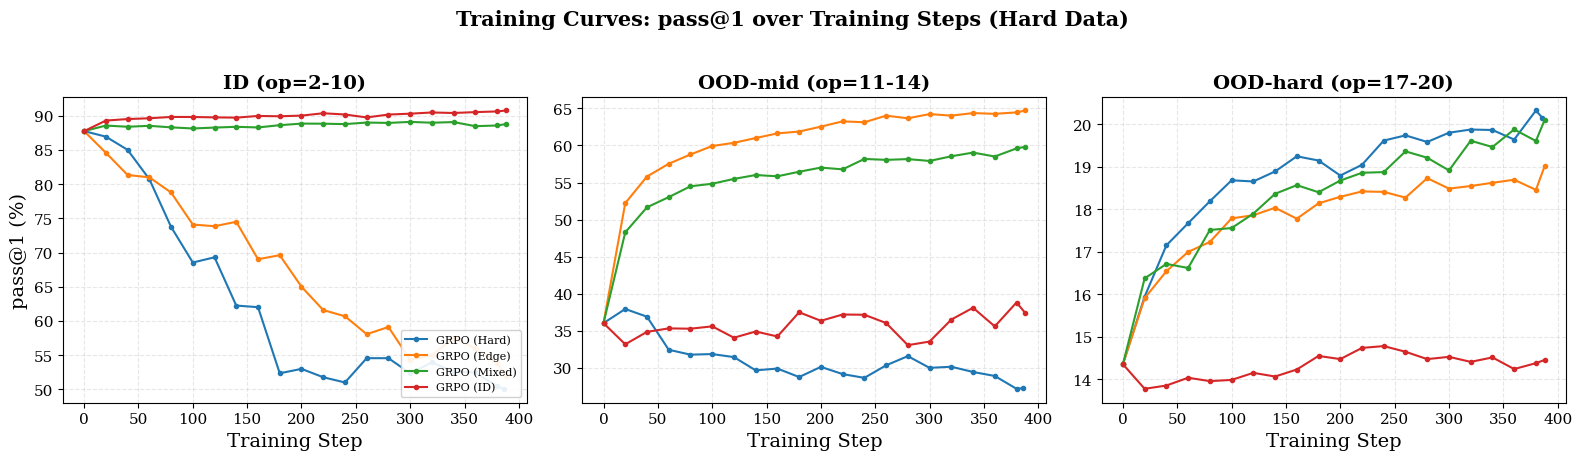

In [20]:
# ── Plot 9: Training curves for Edge data regime ─────────────────────────────

training_runs_hard = [
    "dr_gspo_hard",
    "dr_gspo_clip_cov_hard",
    "dr_gspo_mgpo_hard",
    "dr_gspo_rup_hard",
]


training_runs_hard = [
    "grpo_hard",
    "grpo_edge",
    "grpo_mixed",
    "grpo_id",
]
training_colors_hard = {
    "GRPO (Hard)":          "#1f77b4",
    "GRPO (Edge)":  "#ff7f0e",
    "GRPO (Mixed)":     "#2ca02c",
    "GRPO (ID)":      "#d62728",
}


# training_colors_hard = {
#     "DR-GSPO (Hard)":          "#1f77b4",
#     "DR-GSPO-ClipCov (Hard)":  "#ff7f0e",
#     "DR-GSPO-MGPO (Hard)":     "#2ca02c",
#     "DR-GSPO-RUP (Hard)":      "#d62728",
# }

fig9a = plot_training_curves(
    training_runs_hard,
    k=1,
    title="Training Curves: pass@1 over Training Steps (Hard Data)",
    colors=training_colors_hard,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_training_curves_hard.png",
)

Saved to /fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_midtrain_vs_final_mixed.png


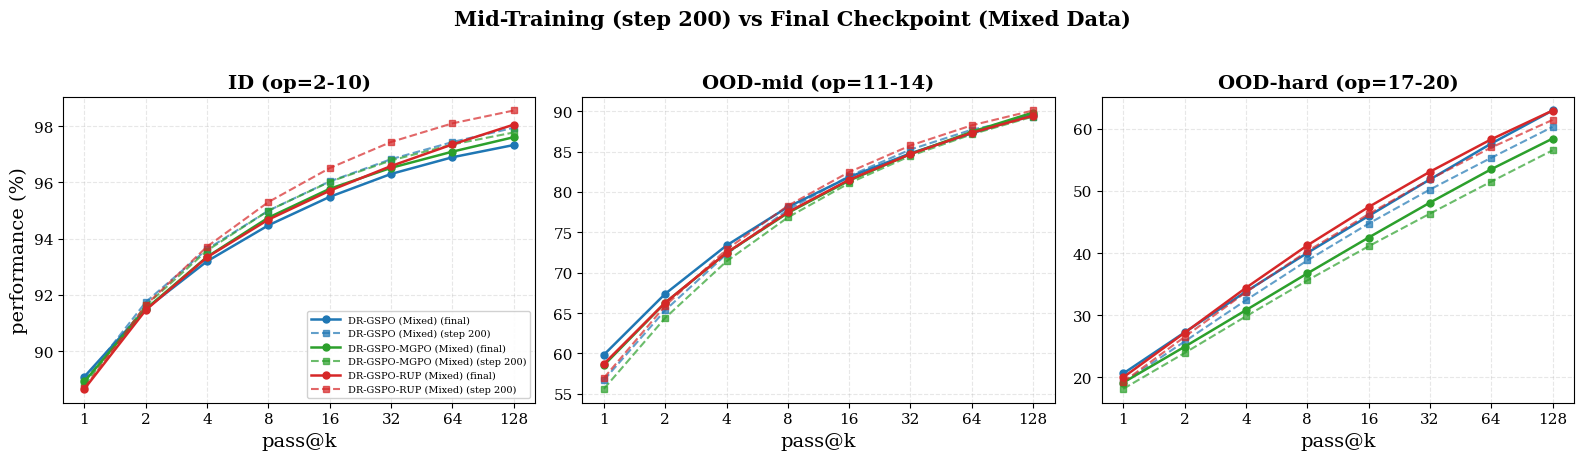

In [13]:
# ── Plot 10: Mid-training checkpoint comparison (step 200 vs final) ──────────
# Compare pass@k at an intermediate checkpoint vs final checkpoint

def plot_pass_at_k_comparison(
    run_groups: dict[str, list[str]],
    step_early: int,
    step_final: int | None = None,
    title: str = "",
    colors: dict[str, str] | None = None,
    figsize: tuple = (16, 4.5),
    save_path: str | None = None,
):
    """
    Plot pass@k at two different training steps (early vs final).
    Solid lines = final, dashed lines = early checkpoint.
    """
    group_names = list(DIFFICULTY_GROUPS.keys())
    k_values = PASS_K_VALUES
    
    # Load data for all runs at both steps
    all_run_names = []
    for runs in run_groups.values():
        all_run_names.extend(runs)
    all_run_names = list(set(all_run_names))
    
    # Load at both steps
    data_early = {}
    data_final = {}
    for run_name in all_run_names:
        try:
            from process_results import get_pass_at_k_for_run
            data_early[run_name] = get_pass_at_k_for_run(run_name, step_early)
            data_final[run_name] = get_pass_at_k_for_run(run_name, step_final)
        except Exception as e:
            print(f"Warning: Failed to load {run_name}: {e}")
    
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=False)
    
    for ax_idx, group_name in enumerate(group_names):
        ax = axes[ax_idx]
        
        for label, run_names in run_groups.items():
            run_name = run_names[0]
            if run_name not in data_final:
                continue
            
            color = colors.get(label) if colors else None
            
            # Final checkpoint (solid)
            y_final = [data_final[run_name][group_name][k] * 100 for k in k_values]
            ax.plot(
                range(len(k_values)), y_final,
                marker="o", markersize=5, linewidth=1.8,
                color=color, linestyle="-",
                label=f"{label} (final)" if ax_idx == 0 else None,
            )
            
            # Early checkpoint (dashed)
            if run_name in data_early:
                y_early = [data_early[run_name][group_name][k] * 100 for k in k_values]
                ax.plot(
                    range(len(k_values)), y_early,
                    marker="s", markersize=4, linewidth=1.5,
                    color=color, linestyle="--", alpha=0.7,
                    label=f"{label} (step {step_early})" if ax_idx == 0 else None,
                )
        
        ax.set_title(group_name, fontweight="bold")
        ax.set_xticks(range(len(k_values)))
        ax.set_xticklabels([str(k) for k in k_values])
        ax.set_xlabel("pass@k")
        ax.grid(True, alpha=0.3, linestyle="--")
    
    axes[0].set_ylabel("performance (%)")
    axes[0].legend(loc="lower right", framealpha=0.9, fontsize=7, handlelength=3.0)
    
    if title:
        fig.suptitle(title, fontweight="bold", fontsize=15, y=1.02)
    fig.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to {save_path}")
    
    plt.show()
    return fig

# Compare step 200 (mid-training) vs final for DR-GSPO variants on Mixed
run_groups_midtrain = {
    "DR-GSPO (Mixed)":          ["dr_gspo_mixed"],
    "DR-GSPO-ClipCov (Mixed)":  ["dr_gspo_clip_cov_mixed"],
    "DR-GSPO-MGPO (Mixed)":     ["dr_gspo_mgpo_mixed"],
    "DR-GSPO-RUP (Mixed)":      ["dr_gspo_rup_mixed"],
}

colors_midtrain = {
    "DR-GSPO (Mixed)":          "#1f77b4",
    "DR-GSPO-ClipCov (Mixed)":  "#ff7f0e",
    "DR-GSPO-MGPO (Mixed)":     "#2ca02c",
    "DR-GSPO-RUP (Mixed)":      "#d62728",
}

fig10 = plot_pass_at_k_comparison(
    run_groups_midtrain,
    step_early=200,
    step_final=None,  # uses latest
    title="Mid-Training (step 200) vs Final Checkpoint (Mixed Data)",
    colors=colors_midtrain,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_midtrain_vs_final_mixed.png",
)

In [ ]:
# ── Plot 11: Mid-training comparison for Edge data ───────────────────────────

run_groups_midtrain_edge = {
    "DR-GSPO (Edge)":          ["dr_gspo_edge"],
    "DR-GSPO-ClipCov (Edge)":  ["dr_gspo_clip_cov_edge"],
    "DR-GSPO-MGPO (Edge)":     ["dr_gspo_mgpo_edge"],
    "DR-GSPO-RUP (Edge)":      ["dr_gspo_rup_edge"],
}

colors_midtrain_edge = {
    "DR-GSPO (Edge)":          "#1f77b4",
    "DR-GSPO-ClipCov (Edge)":  "#ff7f0e",
    "DR-GSPO-MGPO (Edge)":     "#2ca02c",
    "DR-GSPO-RUP (Edge)":      "#d62728",
}

fig11 = plot_pass_at_k_comparison(
    run_groups_midtrain_edge,
    step_early=200,
    step_final=None,
    title="Mid-Training (step 200) vs Final Checkpoint (Edge Data)",
    colors=colors_midtrain_edge,
    save_path="/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/fig_midtrain_vs_final_edge.png",
)